# Sistema de Rossler

Investigar el sistema de Rossler:

$ \dot{x} = -y -z $

$ \dot{y} = x + ay $

$ \dot{z} = b + z(x - c) $

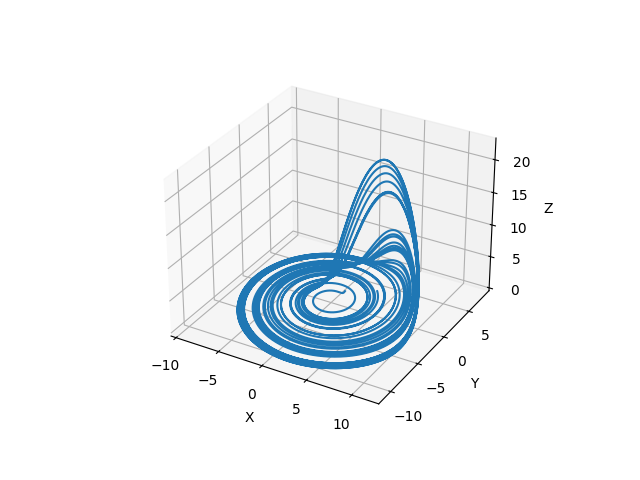

In [5]:
# Sistema de Rossler
import fcl1109 as fcl
import numpy as np

def rossler(t, state):
    x, y, z = state
    a = 0.2
    b = 0.2
    c = 5.7

    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)

    return np.array([dxdt, dydt, dzdt], dtype=float)

# Parámetros de la simulación
t0 = 0.0
tf = 200.0
h = 0.01
N = int((tf - t0) / h)

# Condiciones iniciales
y0 = np.array([1.0, 1.0, 1.0])

# Simulación
t_values = np.linspace(t0, tf, N)
y_values = np.zeros((N, 3))
y_values[0] = y0

for i in range(1, N):
    y_values[i] = fcl.rk4(rossler, t_values[i-1], y_values[i-1], h)

# Graficar los resultados
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(y_values[:, 0], y_values[:, 1], y_values[:, 2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

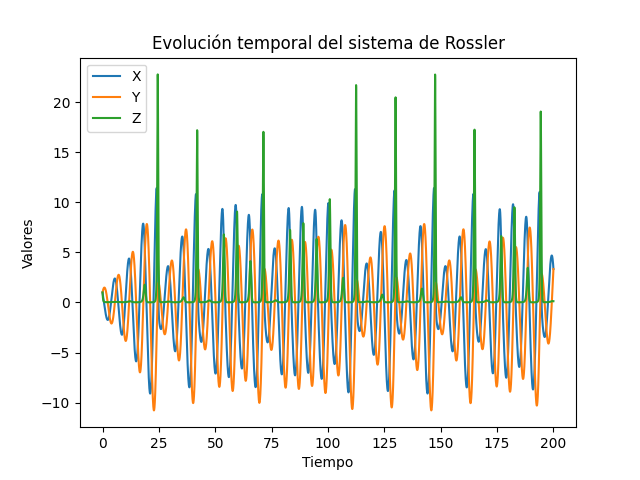

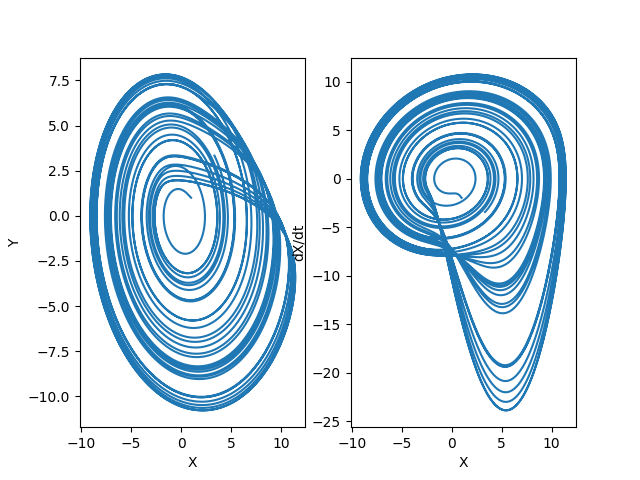

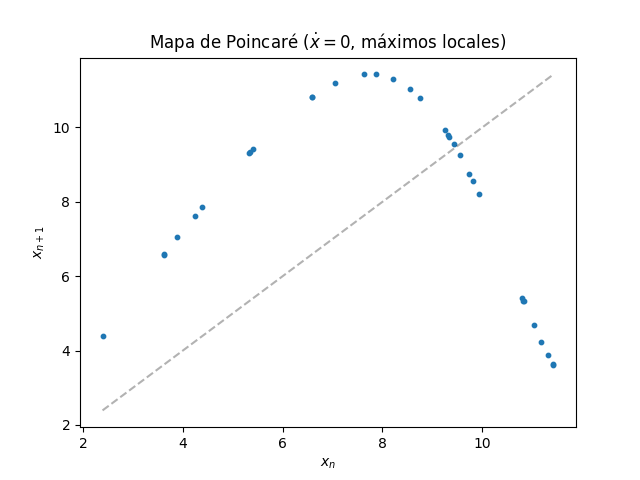

In [6]:
# Evolución temporal
plt.figure()
plt.plot(t_values, y_values[:, 0], label='X')
plt.plot(t_values, y_values[:, 1], label='Y')
plt.plot(t_values, y_values[:, 2], label='Z')
plt.xlabel('Tiempo')
plt.ylabel('Valores')
plt.legend()
plt.title('Evolución temporal del sistema de Rossler')
plt.show()

# Proyección en (x,y) y (x, dx/dt)
plt.figure()
plt.subplot(1, 2, 1)
plt.plot(y_values[:, 0], y_values[:, 1])
plt.xlabel('X')
plt.ylabel('Y')
plt.subplot(1, 2, 2)
dxdt = np.gradient(y_values[:, 0], h)
plt.plot(y_values[:, 0], dxdt)
plt.xlabel('X')
plt.ylabel('dX/dt')
plt.show()

# Mapa de Poincaré: sección en dx/dt = 0 (máximos locales de x)
# Se buscan cruces donde dx/dt pasa de positivo a negativo (máximos)
# y se interpola linealmente para encontrar el valor exacto de x en el máximo
x_maxima = []
for i in range(1, N):
    if dxdt[i-1] > 0 and dxdt[i] <= 0:
        # Interpolación lineal para el cruce exacto
        alpha = dxdt[i-1] / (dxdt[i-1] - dxdt[i])
        x_max = y_values[i-1, 0] + alpha * (y_values[i, 0] - y_values[i-1, 0])
        x_maxima.append(x_max)

# Mapa de retorno: x_{n+1} vs x_n
x_maxima = np.array(x_maxima)
plt.figure()
plt.scatter(x_maxima[:-1], x_maxima[1:], s=10)
plt.xlabel(r'$x_n$')
plt.ylabel(r'$x_{n+1}$')
plt.title(r'Mapa de Poincaré ($\dot{x} = 0$, máximos locales)')
# Línea identidad para referencia
lims = [min(x_maxima), max(x_maxima)]
plt.plot(lims, lims, 'k--', alpha=0.3)
plt.show()

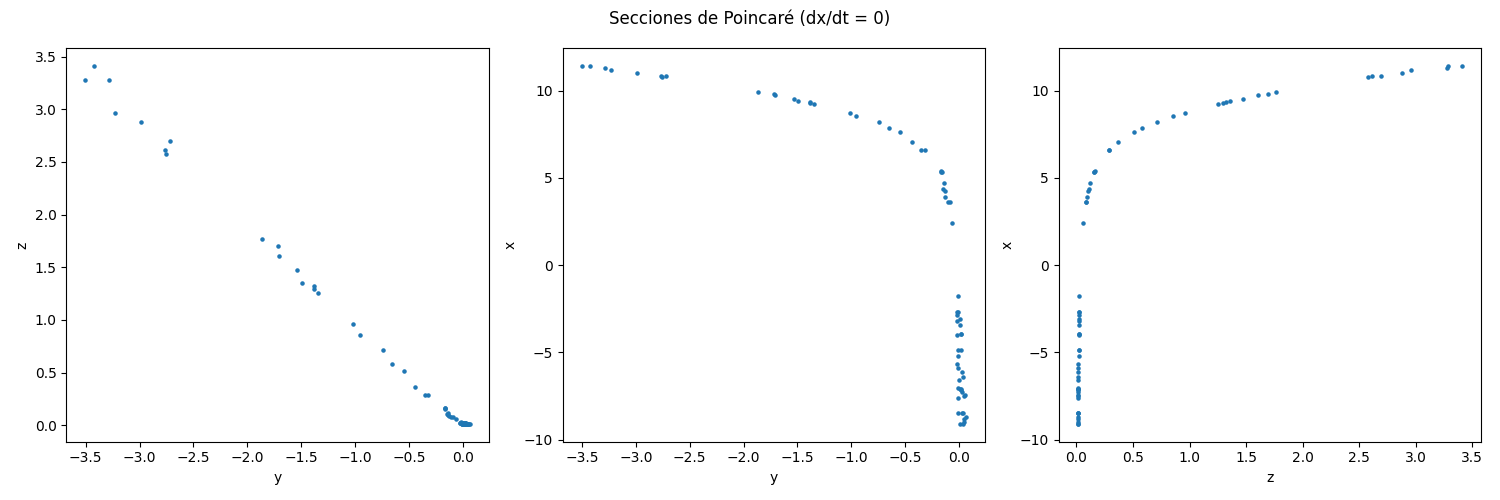

In [7]:
# Secciones de Poincaré geométricas (dx/dt = 0)
# Detectar cruces por cero de dx/dt
indices = np.where(np.diff(np.sign(dxdt)))[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Secciones de Poincaré (dx/dt = 0)')

axes[0].scatter(y_values[indices, 1], y_values[indices, 2], s=5)
axes[0].set_xlabel('y')
axes[0].set_ylabel('z')

axes[1].scatter(y_values[indices, 1], y_values[indices, 0], s=5)
axes[1].set_xlabel('y')
axes[1].set_ylabel('x')

axes[2].scatter(y_values[indices, 2], y_values[indices, 0], s=5)
axes[2].set_xlabel('z')
axes[2].set_ylabel('x')

plt.tight_layout()
plt.show()

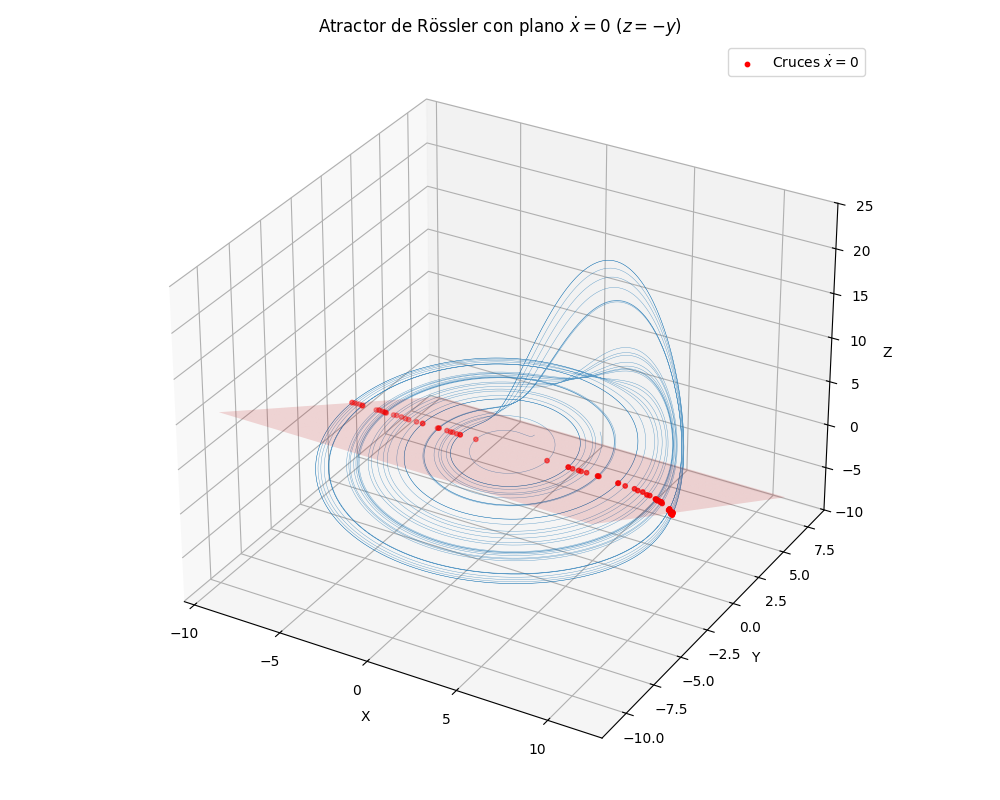

In [8]:
%matplotlib widget
# Atractor 3D con plano de sección de Poincaré (dx/dt = 0 → z = -y)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Atractor
ax.plot(y_values[:, 0], y_values[:, 1], y_values[:, 2], lw=0.3, alpha=0.7)

# Puntos de cruce sobre el plano
ax.scatter(y_values[indices, 0], y_values[indices, 1], y_values[indices, 2],
           c='r', s=10, zorder=5, label=r'Cruces $\dot{x}=0$')

# Plano z = -y: crear malla en (x, y) y calcular z = -y
y_range = np.linspace(y_values[:, 1].min(), y_values[:, 1].max(), 20)
x_range = np.linspace(y_values[:, 0].min(), y_values[:, 0].max(), 20)
Y_plane, X_plane = np.meshgrid(y_range, x_range)
Z_plane = -Y_plane

ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.15, color='red')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(r'Atractor de Rössler con plano $\dot{x}=0$ ($z = -y$)')
ax.legend()
plt.tight_layout()
plt.show()